# Pricing Under Limited Information - Execution Example

This notebook is the computational execution example for the uncertainty-propagation methodology described in the accompanying paper. It shows the sequence:

**limited observations → parameter uncertainty → plausible demand curves → plausible revenue curves → distribution of optimal prices**

The Poisson log-linear demand model used here is only a simple example chosen to keep the execution transparent. The methodology itself is model agnostic.


## 1. Define a Simple True Demand Function and Generate Limited Observations

For the execution example, the true expected demand is defined as

$$\lambda(p)=1350e^{-0.05p}.$$

Six price levels between 10 and 30 are observed for 15 periods each, resulting in 90 historical observations. Sales are generated with Poisson noise.


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def true_demand(p):
    return 1350 * np.exp(-0.05 * p)

def get_sales(p, noise_scale=0.5):
    mean = true_demand(p)
    return rng.poisson(mean * noise_scale) / noise_scale

month_prices = rng.choice(30 - 10, size=6, replace=False) + 10
prices = [int(p) for p in month_prices for _ in range(15)]
demand = [get_sales(p) for p in prices]

df = pd.DataFrame({'t': np.arange(len(prices)), 'price': prices, 'demand': demand})
df['revenue'] = df['price'] * df['demand']
df.head()


,t,price,demand,revenue
0,0,21,498.0,10458.0
1,1,21,432.0,9072.0
2,2,21,460.0,9660.0
3,3,21,486.0,10206.0
4,4,21,468.0,9828.0


## 2. Estimate the Demand Curve

A Poisson GLM with log link is used for this simple execution example:

$$Q_t\mid p_t\sim\operatorname{Poisson}(\lambda_t),$$

$$\log(\lambda_t)=a+b p_t.$$

The fitted coefficients provide the point estimate of the demand relationship and their covariance matrix provides the uncertainty representation used in the next step.


In [2]:
X = sm.add_constant(df['price'].values)
y = df['demand'].values

poisson_model = sm.GLM(y, X, family=sm.families.Poisson(link=sm.families.links.log()))
res = poisson_model.fit()
res.summary()


/opt/pyvenv/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                   90
Model:                            GLM   Df Residuals:                       88
Model Family:                 Poisson   Df Model:                            1
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -444.60
Date:                Fri, 25 Sep 2026   Deviance:                       162.78
Time:                        18:53:01   Pearson chi2:                     163.
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.2200      0.017    416.713      0.000       7.186       7.254
x1            -0.0509      0.001    -55.142      0.000      -0.053      -0.049
==============================================================================
"""

## 3. Generate Plausible Parameter Vectors

Let $\hat \theta = (\hat a,\hat b)$ and $\widehat \Sigma$ be the fitted coefficient vector and covariance matrix. Plausible parameter vectors are sampled jointly from

$$\theta^{(j)}\sim\mathcal N(\hat{\theta},\widehat \Sigma).$$

The example retains only draws in which both coefficients fall within their marginal 95% confidence intervals. This is a transparent admissibility rule for the demonstration, not a claim that the rectangular region is an exact joint confidence region.


In [ ]:
confidence_intervals = np.asarray(res.conf_int())
coef_cov = np.asarray(res.cov_params())
coef_mean = np.asarray(res.params)

n_curves = 500
parameter_draws = []

while len(parameter_draws) < n_curves:
    draws = rng.multivariate_normal(coef_mean, coef_cov, size=n_curves)

    inside_ci = (
        (draws[:, 0] >= confidence_intervals[0, 0]) &
        (draws[:, 0] <= confidence_intervals[0, 1]) &
        (draws[:, 1] >= confidence_intervals[1, 0]) &
        (draws[:, 1] <= confidence_intervals[1, 1])
    )

    parameter_draws.extend(draws[inside_ci].tolist())

parameter_draws = np.asarray(parameter_draws[:n_curves])
pd.DataFrame(parameter_draws, columns=['a', 'b']).describe()


,a,b
count,500.000000,500.000000
mean,7.219954,-0.050946
std,0.014613,0.000790
min,7.186974,-0.052680
25%,7.209883,-0.051509
50%,7.219998,-0.050967
75%,7.230904,-0.050329
max,7.253549,-0.049146


## 4. Propagate Parameter Uncertainty to Plausible Demand Curves

Each retained parameter vector defines one plausible demand curve:

$$\lambda^{(j)}(p)=\exp(a^{(j)}+b^{(j)}p).$$

The same candidate price grid is used for all plausible realizations.


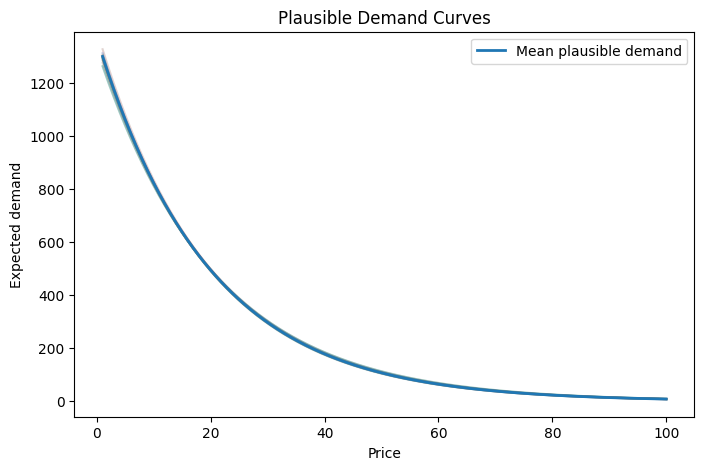

In [ ]:
price_grid = np.linspace(1, 100, 500)

log_demand_curves = (
    parameter_draws[:, 0, None]
    + parameter_draws[:, 1, None] * price_grid[None, :]
)

demand_curves = np.exp(log_demand_curves)

plt.figure(figsize=(8, 5))

for curve in demand_curves[::25]:
    plt.plot(price_grid, curve, alpha=0.25)

plt.plot(price_grid, demand_curves.mean(axis=0), linewidth=2, label='Mean plausible demand')
plt.xlabel('Price')
plt.ylabel('Expected demand')
plt.title('Plausible Demand Curves')
plt.legend()
plt.show()


## 5. Propagate Demand Uncertainty to Revenue Curves

For each plausible demand curve, the corresponding revenue curve is

$$R^{(j)}(p)=p\lambda^{(j)}(p).$$


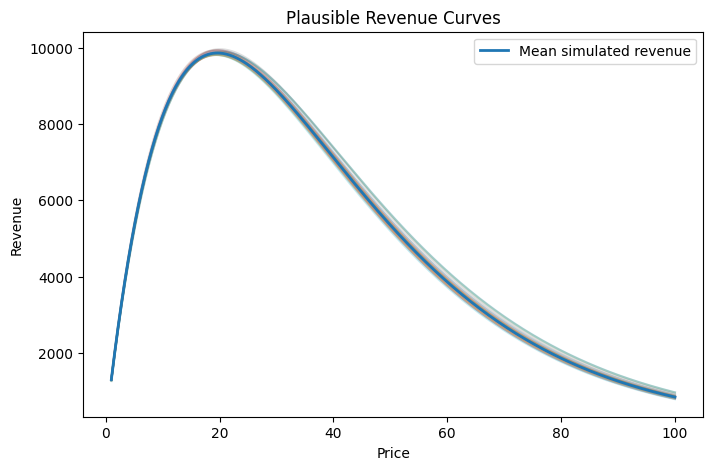

In [5]:
revenue_curves = demand_curves * price_grid[None, :]
expected_revenue = revenue_curves.mean(axis=0)

plt.figure(figsize=(8, 5))
for curve in revenue_curves[::25]:
    plt.plot(price_grid, curve, alpha=0.25)
plt.plot(price_grid, expected_revenue, linewidth=2, label='Mean simulated revenue')
plt.xlabel('Price')
plt.ylabel('Revenue')
plt.title('Plausible Revenue Curves')
plt.legend()
plt.show()


## 6. Obtain the Distribution of Optimal Prices

Each plausible revenue curve is optimized over the candidate price grid:

$$p_j^*=\operatorname*{arg\,max}_{p\in\mathcal P}R^{(j)}(p).$$

The resulting set of optimal prices shows how parameter uncertainty is transmitted to the pricing decision. A central decision is also obtained by maximizing mean simulated revenue across the plausible models.


In [ ]:
optimal_index = np.argmax(revenue_curves, axis=1)
optimal_prices = price_grid[optimal_index]
optimal_revenues = revenue_curves[np.arange(n_curves), optimal_index]

central_index = np.argmax(expected_revenue)
central_price = price_grid[central_index]

summary = pd.Series({
    'central_price_expected_revenue': central_price,
    'mean_optimal_price': optimal_prices.mean(),
    'median_optimal_price': np.median(optimal_prices),
    'optimal_price_p2.5': np.quantile(optimal_prices, 0.025),
    'optimal_price_p97.5': np.quantile(optimal_prices, 0.975),
})

summary


central_price_expected_revenue    19.649299
mean_optimal_price                19.629459
median_optimal_price              19.649299
optimal_price_p2.5                19.054108
optimal_price_p97.5               20.244489
dtype: float64

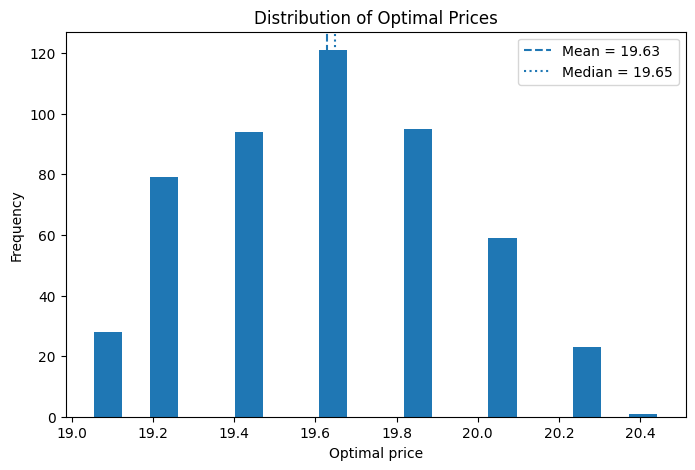

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(optimal_prices, bins=20)
plt.axvline(optimal_prices.mean(), linestyle='--', label=f'Mean = {optimal_prices.mean():.2f}')
plt.axvline(np.median(optimal_prices), linestyle=':', label=f'Median = {np.median(optimal_prices):.2f}')
plt.xlabel('Optimal price')
plt.ylabel('Frequency')
plt.title('Distribution of Optimal Prices')
plt.legend()
plt.show()


## 7. Inspect and Explain the Result

The execution exposes the complete path from coefficient uncertainty to the final pricing decision. The fitted coefficient vector and covariance matrix can be inspected directly; the plausible demand and revenue curves show the effect of alternative parameter realizations; and the distribution of $p_j^*$ shows the sensitivity of the optimal price to that uncertainty.

For this simple log-linear revenue example, the unconstrained analytical optimum satisfies $p^*=-1/b$ when $b<0$. This provides a transparent validation check for the numerical optimizer. The general methodology does not depend on this closed-form result and can use numerical optimization for other demand models, costs, constraints, and additional covariates.
